In [1]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [4]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [5]:
no_aug_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

SSR_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
train_ds = filter_by_elev(SSR_synth_ds, {14, 15, 16})
valid_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds = filter_by_elev(meas_ds, {17})

ds_dict = {"train" : train_ds, "val": valid_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "val": len(valid_ds), "test": len(test_ds)}

In [8]:
seed_lst = [10, 42, 100, 123, 666]
 
train_loss = []
val_loss = []
train_acc = []
val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
 
    model = models.resnet18(weights = None)

    # Replace final layer for the number of classes
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.classes))
    )

    for layer in model.modules():
        if isinstance(layer, nn.Conv2d):
            layer.padding_mode = "circular"
 
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss() # most common used nn for classification problems
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
    
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:
            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.10f} Acc: {epoch_acc:.10f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_circularpad_only.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 2.2220816032 Acc: 0.2183622829
val Loss: 2.6740695655 Acc: 0.1166253102
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 1.4580490142 Acc: 0.4838709677
val Loss: 1.2252205544 Acc: 0.5719602978
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.8024567330 Acc: 0.6997518610
val Loss: 1.9071786289 Acc: 0.3598014888
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.5663690626 Acc: 0.7940446650
val Loss: 0.9084428570 Acc: 0.6848635236
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.3322474658 Acc: 0.8920595533
val Loss: 0.5746606007 Acc: 0.8300248139
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.2726191072 Acc: 0.9143920596
val Loss: 0.8879102358 Acc: 0.7282878412
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.2037230812 Acc: 0.9317617866
val Loss: 0.8099924620 Acc: 0.8312655087
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.1575349280 Acc: 0.9528535980
val Loss: 1.0798192456 Acc: 0.6898263027
Epoch 7 LR: 0.0002988184
Epoch 8
train

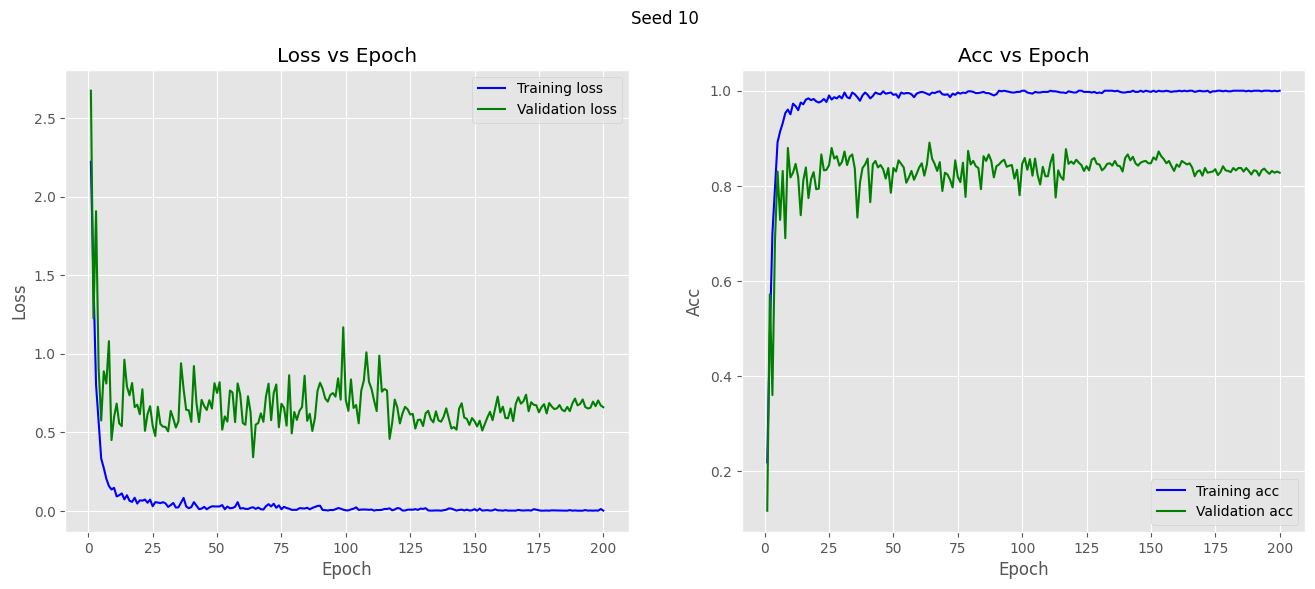

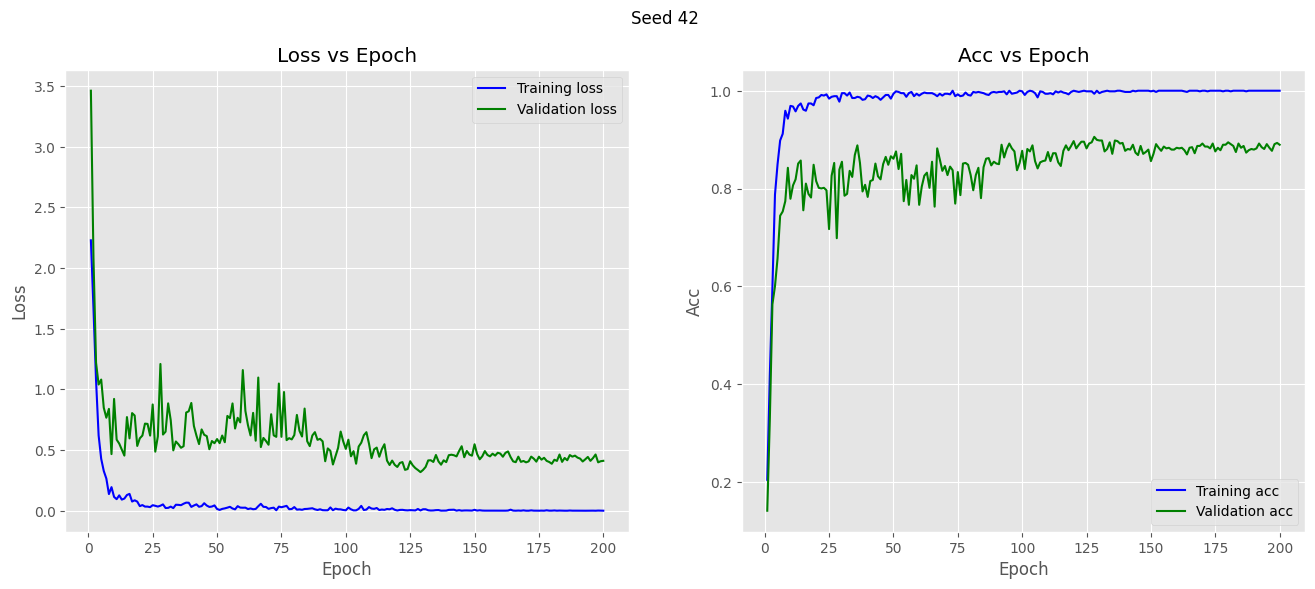

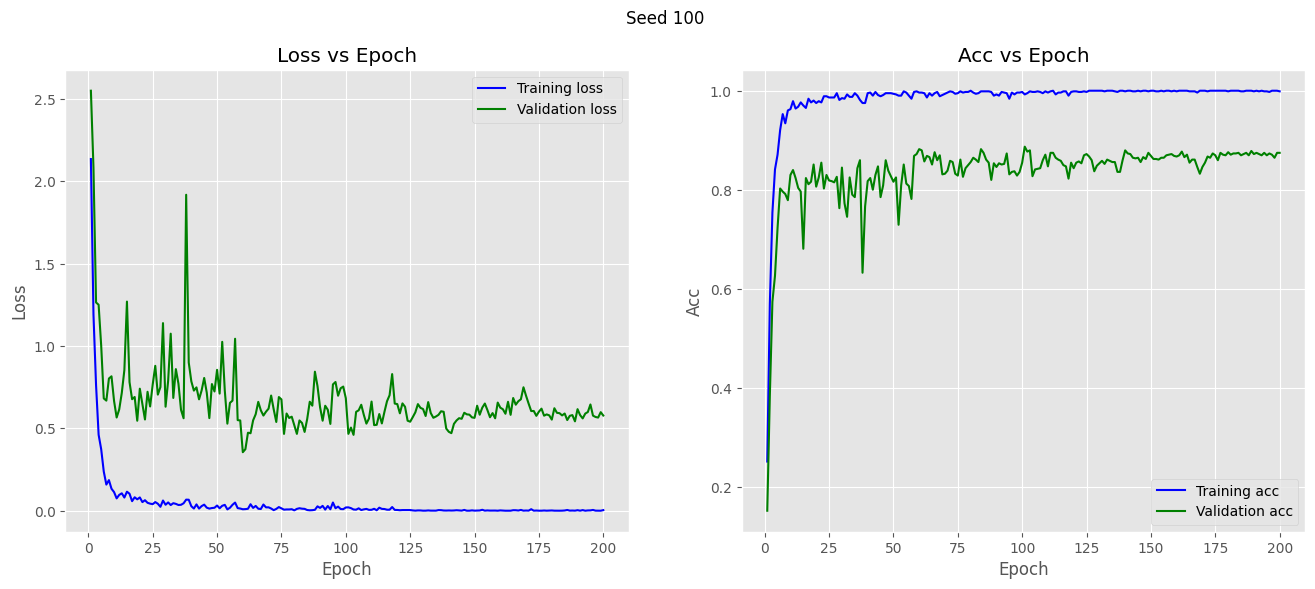

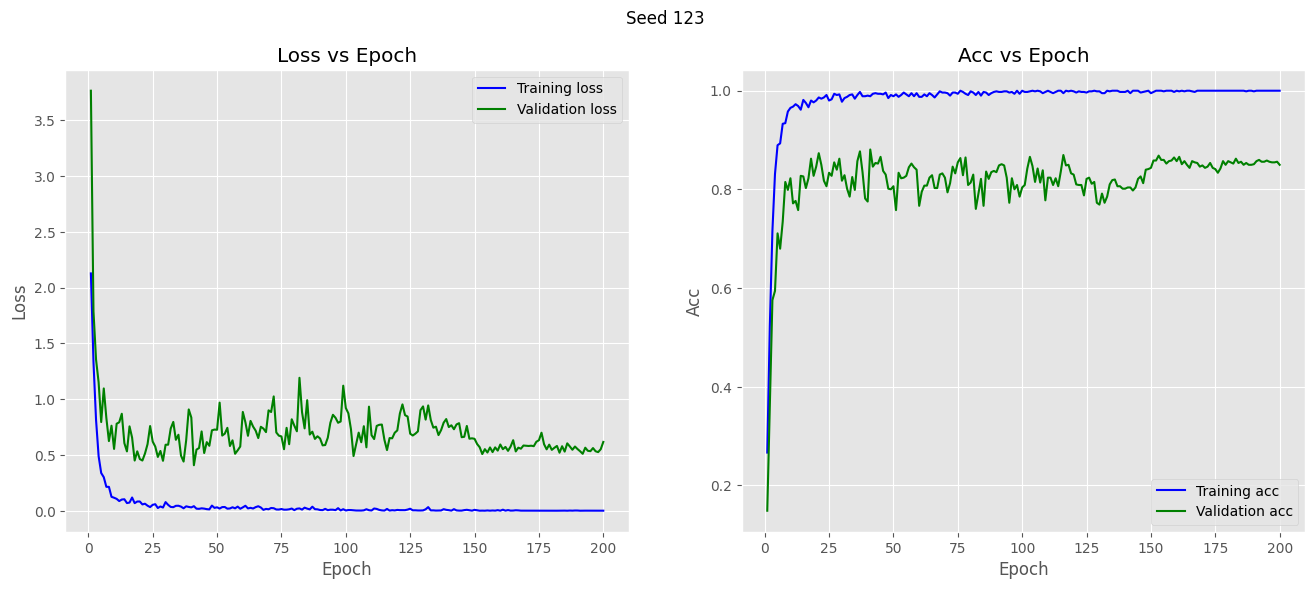

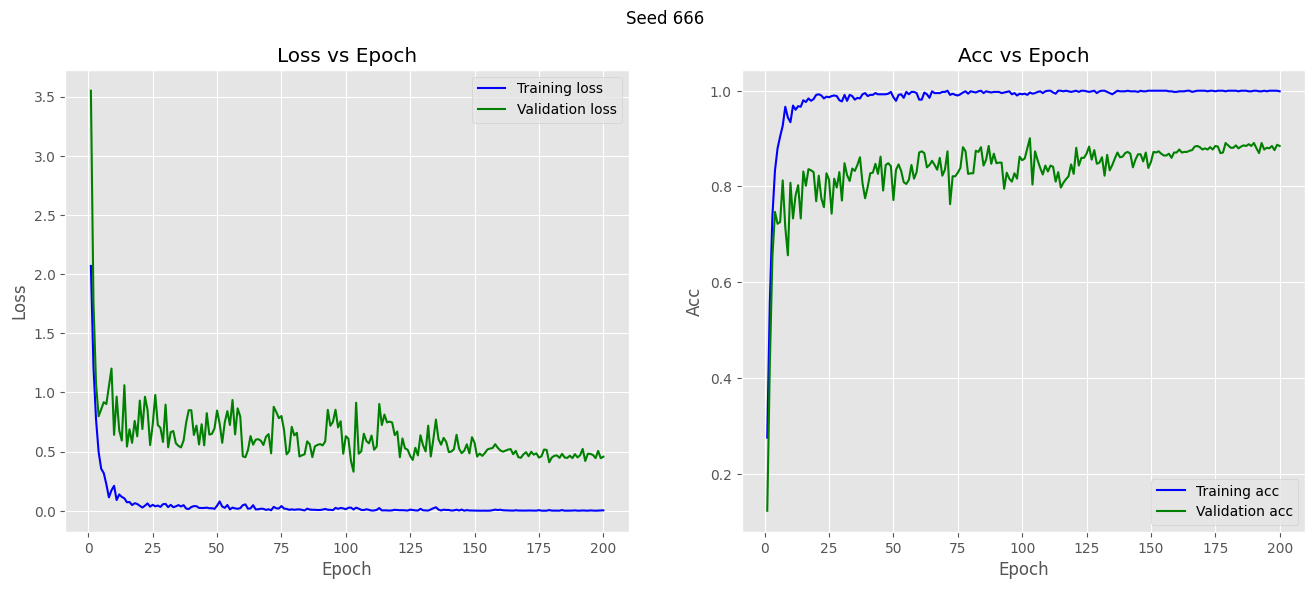

In [9]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [7]:
seed_lst = [10, 42, 100, 123, 666]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None)
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.classes))
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_circularpad_only.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100*test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
Test Accuracy: 79.4063
Evaluating Run 1: Seed 42
Test Accuracy: 74.5826
Evaluating Run 2: Seed 100
Test Accuracy: 66.6048
Evaluating Run 3: Seed 123
Test Accuracy: 73.4694
Evaluating Run 4: Seed 666
Test Accuracy: 74.7681
Min: 66.6048
Max: 79.4063
Avg, Std: 73.7662, 4.1196


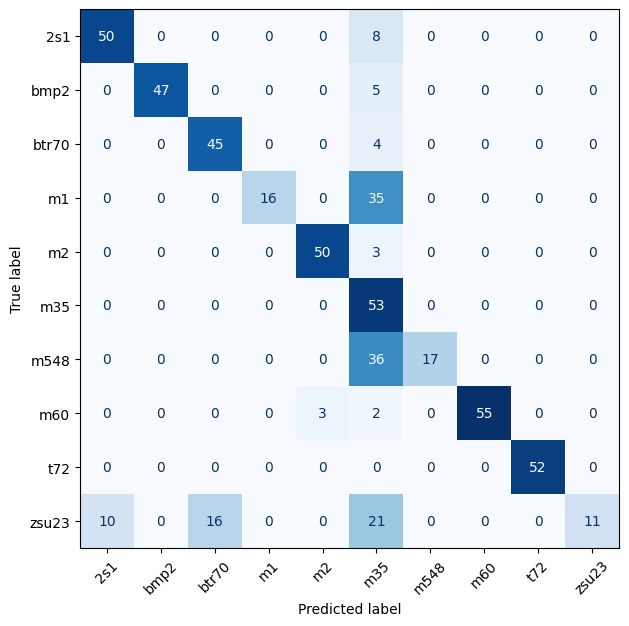

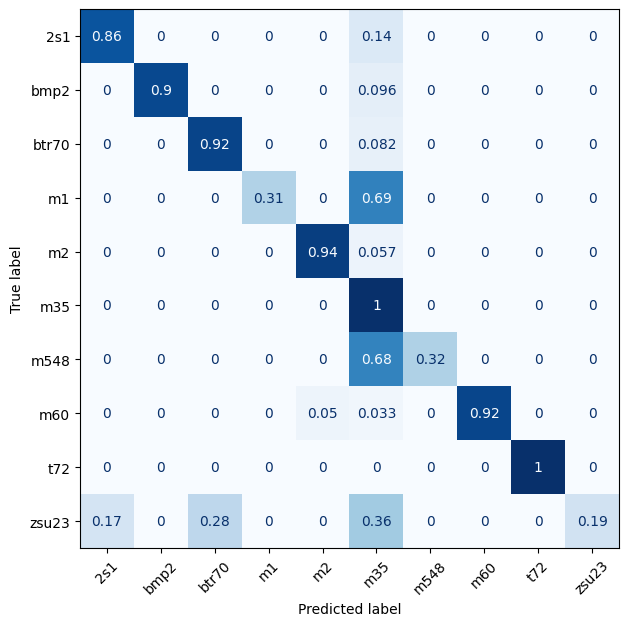

In [10]:
test_dataloader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

seed = 123
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

new_model = models.resnet18(weights = None)
new_model.fc = nn.Sequential(
    nn.Dropout(p = 0.4),
    nn.Linear(new_model.fc.in_features, len(train_ds.classes))
)
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_circularpad_only.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

n_test = len(test_ds)
labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)

idx = 0
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = new_model(inputs)
        _, preds = torch.max(outputs, 1)

        bs = inputs.size(0)
        labels_tensor[idx:idx+bs] = labels
        preds_tensor[idx:idx+bs] = preds
        idx += bs

_labels_all = labels_tensor.cpu().numpy()
_preds_all = preds_tensor.cpu().numpy()

cm = confusion_matrix(_labels_all, _preds_all)
cm_cpu = cp.asnumpy(cm)
disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
cm_norm_cpu = cp.asnumpy(cm_norm)
disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.tick_params(axis='x', rotation=45)
plt.show()

In [8]:
shifted_left_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -5, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_right_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 15, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_up_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_down_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

shifted_left_17 = filter_by_elev(shifted_left_meas_ds, {17})
shifted_right_17 = filter_by_elev(shifted_right_meas_ds, {17})
shifted_up_17 = filter_by_elev(shifted_up_meas_ds, {17})
shifted_down_17 = filter_by_elev(shifted_down_meas_ds, {17})

In [9]:
seed_lst = [10, 42, 100, 123, 666]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for ds in [shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:

    if ds is shifted_left_17:
        print("shifted left by 5 units")
    elif ds is shifted_right_17:
        print("shifted right by 15 units")
    elif ds is shifted_up_17:
        print("shifted up by 10 units")
    elif ds is shifted_down_17:
        print("shifted down by 10 units")
    
    for i, seed in enumerate(seed_lst):
        print(f"Evaluating Run {i}: Seed {seed}")
        new_model = models.resnet18(weights = None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(train_ds.classes))
        )
        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_circularpad_only.pth"),
            map_location=device
        ))
        
        new_model = new_model.to(device)
        new_model.eval()
        
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
                inputs = inputs.to(device)
                labels = labels.to(device)
        
                outputs = new_model(inputs)
                _, preds = torch.max(outputs, 1)
        
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)
        
        test_acc = correct / total
        print(f"Test Accuracy: {100*test_acc:.4f}")
        test_acc_lst.append(test_acc)
    print("\n")

shifted left by 5 units
Evaluating Run 0: Seed 10
Test Accuracy: 25.6030
Evaluating Run 1: Seed 42
Test Accuracy: 13.5436
Evaluating Run 2: Seed 100
Test Accuracy: 7.9777
Evaluating Run 3: Seed 123
Test Accuracy: 10.9462
Evaluating Run 4: Seed 666
Test Accuracy: 10.9462


shifted right by 15 units
Evaluating Run 0: Seed 10
Test Accuracy: 3.3395
Evaluating Run 1: Seed 42
Test Accuracy: 4.2672
Evaluating Run 2: Seed 100
Test Accuracy: 3.5250
Evaluating Run 3: Seed 123
Test Accuracy: 3.1540
Evaluating Run 4: Seed 666
Test Accuracy: 6.6790


shifted up by 10 units
Evaluating Run 0: Seed 10
Test Accuracy: 3.1540
Evaluating Run 1: Seed 42
Test Accuracy: 5.5659
Evaluating Run 2: Seed 100
Test Accuracy: 4.4527
Evaluating Run 3: Seed 123
Test Accuracy: 3.1540
Evaluating Run 4: Seed 666
Test Accuracy: 5.3803


shifted down by 10 units
Evaluating Run 0: Seed 10
Test Accuracy: 6.4935
Evaluating Run 1: Seed 42
Test Accuracy: 5.1948
Evaluating Run 2: Seed 100
Test Accuracy: 3.7106
Evaluating Run 3: 

shifted left by 5 units


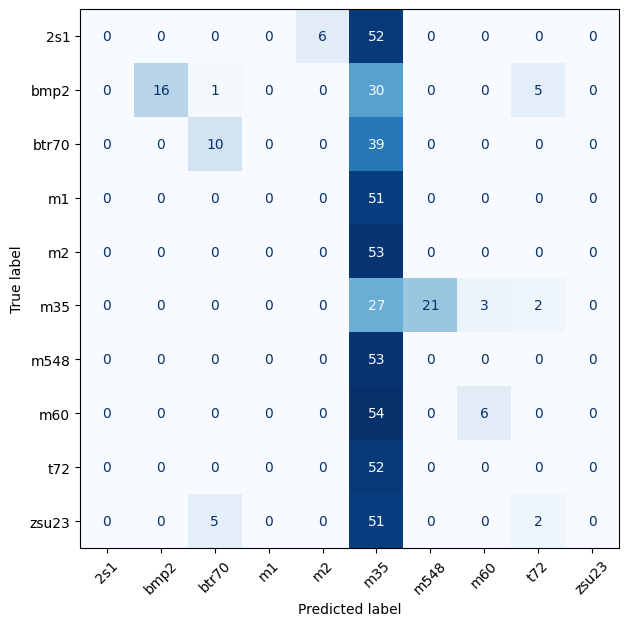

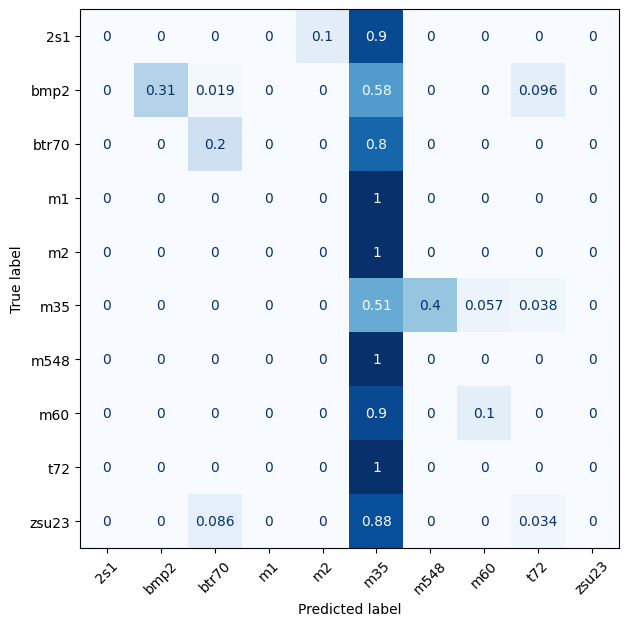

shifted right by 15 units


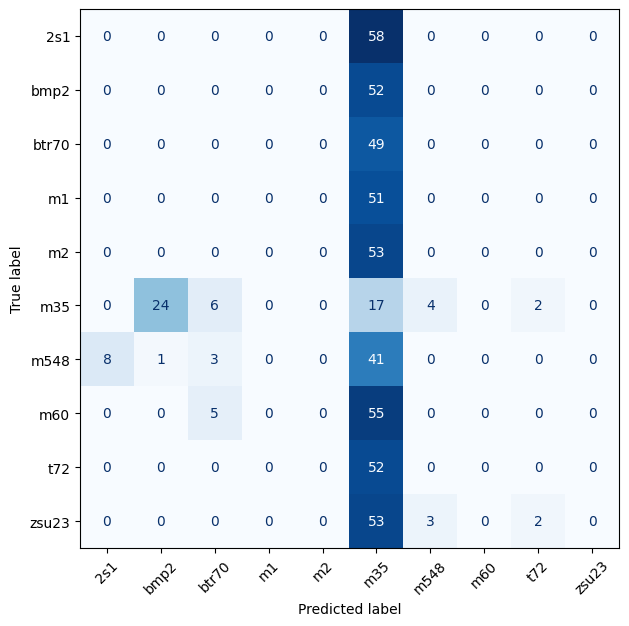

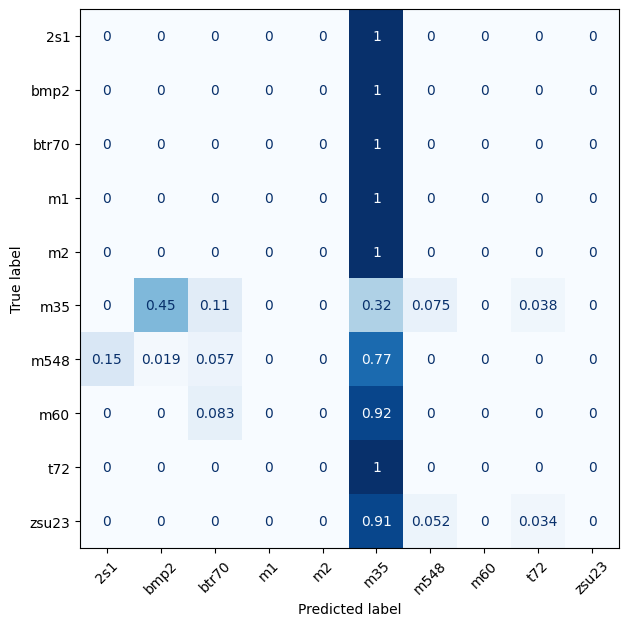

shifted up by 10 units


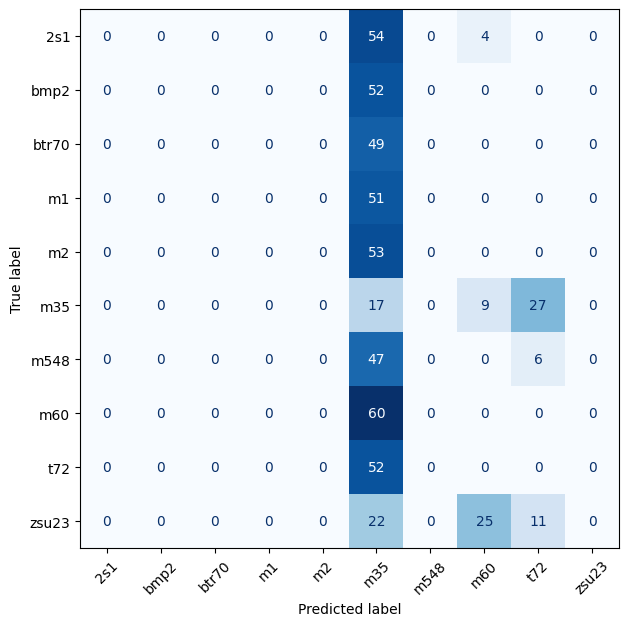

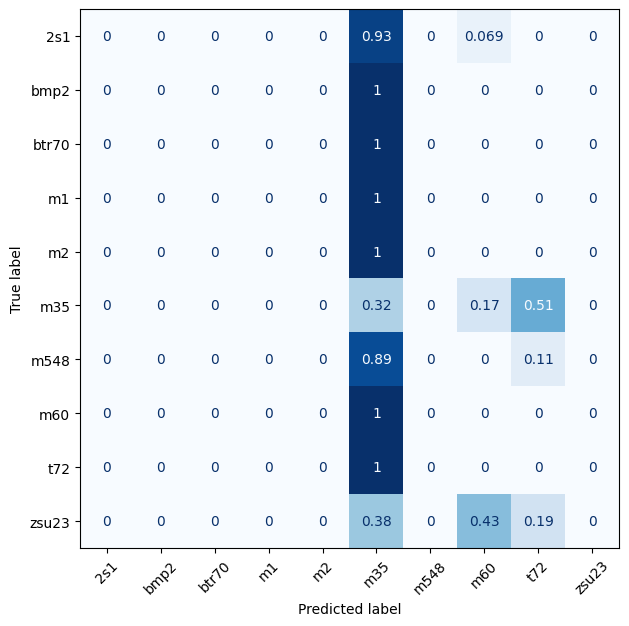

shifted down by 10 units


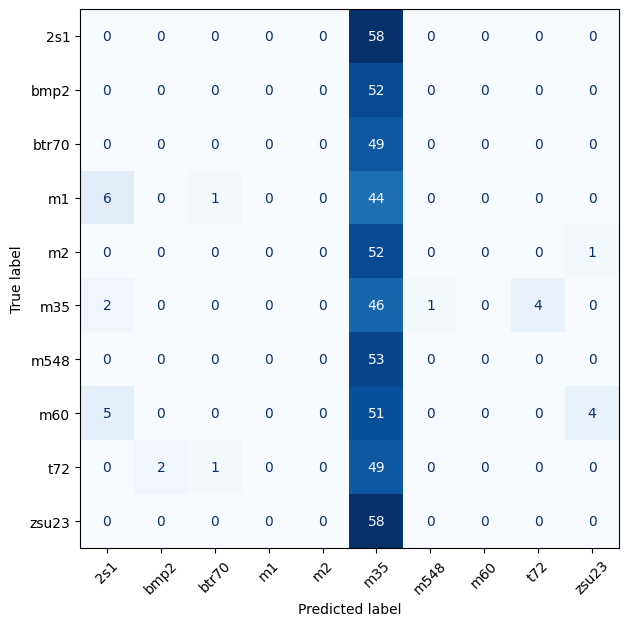

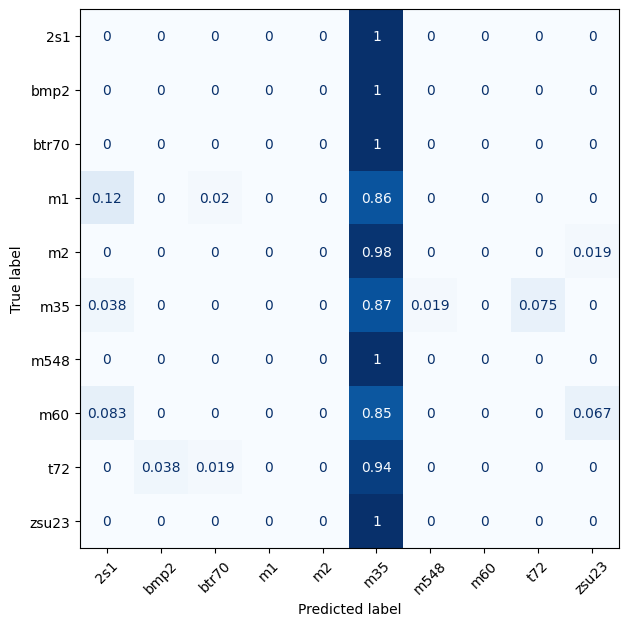

In [13]:
for ds in [shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:

    test_dataloader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

    if ds is shifted_left_17:
        print("shifted left by 5 units")
    elif ds is shifted_right_17:
        print("shifted right by 15 units")
    elif ds is shifted_up_17:
        print("shifted up by 10 units")
    elif ds is shifted_down_17:
        print("shifted down by 10 units")

    seed = 123
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    
    new_model = models.resnet18(weights = None)
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.classes))
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Extras/LPD/SSR_w_noise/rn18_seed{seed}_b16_circularpad_only.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()
    
    n_test = len(test_ds)
    labels_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    preds_tensor = torch.zeros(n_test, dtype=torch.long, device=device)
    
    idx = 0
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            bs = inputs.size(0)
            labels_tensor[idx:idx+bs] = labels
            preds_tensor[idx:idx+bs] = preds
            idx += bs
    
    _labels_all = labels_tensor.cpu().numpy()
    _preds_all = preds_tensor.cpu().numpy()
    
    cm = confusion_matrix(_labels_all, _preds_all)
    cm_cpu = cp.asnumpy(cm)
    disp = ConfusionMatrixDisplay(cm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.tick_params(axis='x', rotation=45)
    plt.show()
    
    cm_norm = confusion_matrix(_labels_all, _preds_all, normalize='true')
    cm_norm_cpu = cp.asnumpy(cm_norm)
    disp = ConfusionMatrixDisplay(cm_norm_cpu, display_labels=list(test_ds.class_to_idx.keys()))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.tick_params(axis='x', rotation=45)
    plt.show()